# Machine Learning Classification of Player Feedback from Steam Reviews

**Student:** Robert Mayfield  
**Project:** Udacity AI Masters Capstone - Applied Machine Learning  
**Series:** AI Game Director Studio (Project 3 of 7)

## 1. Project Overview

This project trains a supervised machine learning classifier to predict whether a player review reflects a positive or negative experience. The classifier takes raw review text as input and produces a binary sentiment signal, converting unstructured player language into a structured output that downstream systems can act on.

### Training data

The model is trained on Steam game reviews using the `voted_up` label, a direct binary recommendation provided by the reviewer. Steam reviews represent the largest publicly available labeled dataset of player generated feedback in natural language, covering 15,437,471 reviews across 8,183 games (forgemaster, 2024).

### What this project produces

The trained classifier and TF-IDF vectorizer are saved as reusable artifacts. Any system that receives player feedback text can load these artifacts and produce a sentiment signal without retraining.

### References

forgemaster. (2024). *Steam Reviews Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/forgemaster/steam-reviews-dataset

## 2. Dataset Loading and Inspection

In [2]:
import os
import json
import pickle
import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from src.inspection import inspect_dataframe

RANDOM_SEED  = 42
TARGET_SAMPLE = 100_000
RAW_ZIP   = Path('../data/raw/archive.zip')
PROCESSED = Path('../data/processed/steam_reviews_sample.csv')
SAMPLE    = Path('../data/sample/steam_reviews_1k.csv')

print(f"Raw archive present: {RAW_ZIP.exists()}")
print(f"Processed sample present: {PROCESSED.exists()}")

Raw archive present: True
Processed sample present: True


In [3]:
if PROCESSED.exists():
    print("Processed sample found - skipping extraction.")
    df = pd.read_csv(PROCESSED)
else:
    print("Building processed sample from archive...")
    PROCESSED.parent.mkdir(parents=True, exist_ok=True)

    frames = []
    with zipfile.ZipFile(RAW_ZIP) as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"CSV files in archive: {len(csv_files)}")
        for name in csv_files:
            with z.open(name) as fh:
                chunk = pd.read_csv(fh, usecols=['appid', 'review', 'voted_up'],
                                    low_memory=False)
                frames.append(chunk)
                print(f"  Loaded {name}: {len(chunk):,} rows")

    raw = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(raw):,}")

    raw = raw.dropna(subset=['review', 'voted_up']).reset_index(drop=True)
    raw['voted_up'] = raw['voted_up'].astype(bool)

    pos = raw[raw['voted_up'] == True]
    neg = raw[raw['voted_up'] == False]
    n_pos = int(TARGET_SAMPLE * len(pos) / len(raw))
    n_neg = int(TARGET_SAMPLE * len(neg) / len(raw))
    sample = pd.concat([
        pos.sample(n=min(len(pos), n_pos), random_state=RANDOM_SEED),
        neg.sample(n=min(len(neg), n_neg), random_state=RANDOM_SEED),
    ]).reset_index(drop=True)

    sample.to_csv(PROCESSED, index=False)
    print(f"Saved: {len(sample):,} rows to {PROCESSED}")
    df = sample

print(f"\nDataset loaded: {len(df):,} rows, {df.shape[1]} columns")

Processed sample found - skipping extraction.

Dataset loaded: 99,999 rows, 3 columns


In [4]:
if not SAMPLE.exists():
    SAMPLE.parent.mkdir(parents=True, exist_ok=True)
    df.sample(n=1000, random_state=RANDOM_SEED).to_csv(SAMPLE, index=False)
    print(f"Saved 1k sample → {SAMPLE}")
else:
    print("1k sample already exists.")

1k sample already exists.


In [5]:
inspect_dataframe(df)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    99,999
Columns: 3

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
appid       int64
voted_up     bool
review        str

MEMORY USAGE
------------------------------------------------------------
Total: 32.03 MB

MISSING VALUES
------------------------------------------------------------
No missing values found.

DUPLICATE ROWS
------------------------------------------------------------
Duplicate rows: 2,882

DESCRIPTIVE STATISTICS (NUMERIC)
------------------------------------------------------------
              appid
count  9.999900e+04
mean   3.050983e+05
std    2.141970e+05
min    1.000000e+01
25%    2.037700e+05
50%    2.836800e+05
75%    4.183700e+05
max    1.046030e+06

DESCRIPTIVE STATISTICS (CATEGORICAL)
------------------------------------------------------------
       review
count   99999
unique  89199
top      good
freq      592

UNIQUE VALU

In [6]:
counts = df['voted_up'].value_counts()
pct    = df['voted_up'].value_counts(normalize=True) * 100
print("Class distribution")
print(f"  Positive (voted_up=True):  {counts[True]:>7,}  ({pct[True]:.1f}%)")
print(f"  Negative (voted_up=False): {counts[False]:>7,}  ({pct[False]:.1f}%)")

Class distribution
  Positive (voted_up=True):   86,944  (86.9%)
  Negative (voted_up=False):  13,055  (13.1%)


The sample contains 99,999 rows across 3 columns (appid, review, voted_up) with no missing values, confirming the dataset is clean on ingestion. Memory usage is 32.03 MB, which is manageable in memory without chunking.

The dataset is strongly class imbalanced: 86,944 positive reviews (86.9%) versus 13,055 negative reviews (13.1%), a ratio of roughly 6.7 to 1. This imbalance reflects real Steam user behavior but means a naive classifier that predicts positive for every review would achieve 86.9% accuracy without learning anything meaningful. Evaluation will therefore emphasize macro F1 score, which weights each class equally regardless of support.

There are 2,882 duplicate rows in the sample. These are likely review texts that appear across multiple games rather than data entry errors. They will be dropped in the data quality review to avoid inflating performance on repeated text.

## 3. Data Quality Review

In [7]:
df['char_count'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

print("Character count:")
print(df['char_count'].describe().round(1).to_string())
print()
print("Word count:")
print(df['word_count'].describe().round(1).to_string())

Character count:
count    99999.0
mean       258.5
std        576.8
min          1.0
25%         22.0
50%         75.0
75%        241.0
max       8000.0

Word count:
count    99999.0
mean        47.1
std        103.2
min          0.0
25%          4.0
50%         14.0
75%         44.0
max       1527.0


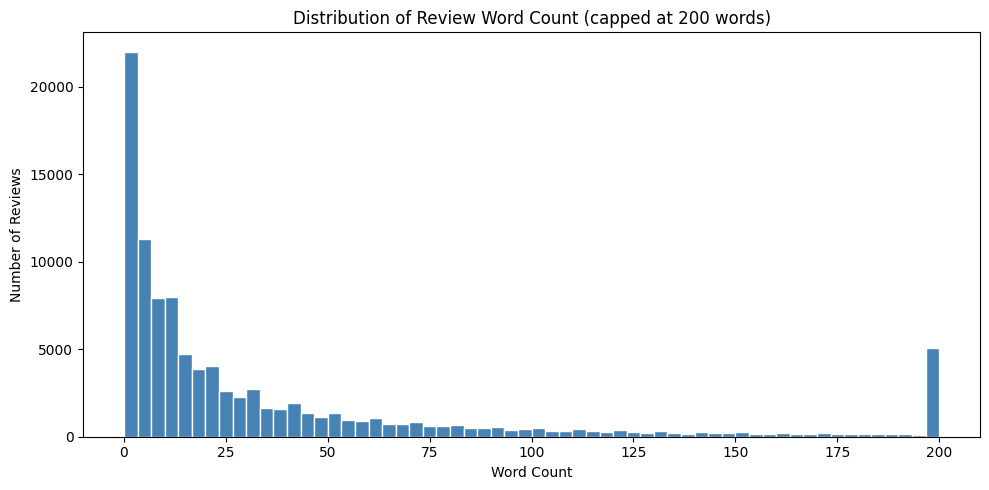

Saved: ..\outputs\figures\review_length_distribution.png


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
capped = df['word_count'].clip(upper=200)
ax.hist(capped, bins=60, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Review Word Count (capped at 200 words)')
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
out = FIGURES / 'review_length_distribution.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

In [9]:
print(f"{'Threshold':<22} {'Count':>8}  {'Percent':>8}")
print("-" * 42)
for t in [3, 5, 10]:
    n = (df['word_count'] < t).sum()
    pct = n / len(df) * 100
    print(f"Under {t} words{'':<14} {n:>8,}  ({pct:>5.1f}%)")

Threshold                 Count   Percent
------------------------------------------
Under 3 words                 16,853  ( 16.9%)
Under 5 words                 26,602  ( 26.6%)
Under 10 words                 41,228  ( 41.2%)


In [10]:
print(f"Maximum character count:          {df['char_count'].max():,}")
print(f"Reviews at exactly 8,000 chars:   {(df['char_count'] == 8000).sum():,}")
print(f"Reviews over 8,000 chars:         {(df['char_count'] > 8000).sum():,}")
print(f"Maximum word count:               {df['word_count'].max():,}")

Maximum character count:          8,000
Reviews at exactly 8,000 chars:   2
Reviews over 8,000 chars:         0
Maximum word count:               1,527


In [11]:
short = df[df['word_count'] < 3][['review', 'voted_up', 'word_count']].head(15)
print(f"Sample of reviews with fewer than 3 words ({(df['word_count'] < 3).sum():,} total):")
print()
print(short.to_string())

Sample of reviews with fewer than 3 words (16,853 total):

           review  voted_up  word_count
11              A      True           1
14    good game\n      True           2
17         Its ok      True           2
25            Yes      True           1
28          Great      True           1
34          its g      True           2
35     Great game      True           2
40    fun game \n      True           2
42           Cool      True           1
43  Damn Khergits      True           2
46        catgirl      True           1
50         mantap      True           1
54              .      True           1
64            ggs      True           1
68          heyoo      True           1


In [12]:
import re

html_pattern = re.compile(r'<[a-zA-Z/][^>]*>')
url_pattern  = re.compile(r'https?://')

df['has_html'] = df['review'].str.contains(html_pattern, regex=True)
df['has_url']  = df['review'].str.contains(url_pattern, regex=True)

print(f"Reviews containing HTML tags: {df['has_html'].sum():,}  ({df['has_html'].mean()*100:.2f}%)")
print(f"Reviews containing URLs:      {df['has_url'].sum():,}  ({df['has_url'].mean()*100:.2f}%)")
print()
print("Sample reviews with HTML:")
for r in df[df['has_html']]['review'].head(3).tolist():
    print(f"  {r[:120]}")
print()
print("Sample reviews with URLs:")
for r in df[df['has_url']]['review'].head(3).tolist():
    print(f"  {r[:120]}")

Reviews containing HTML tags: 31  (0.03%)
Reviews containing URLs:      557  (0.56%)

Sample reviews with HTML:
  I spent the first twelve minutes of this game shooting clouds and tumbleweeds and getting a meat bounty of 9011.  I'm se
  <h1>AWESOME!</h1>

It's even better than Arkham Asylum.

Great story, very good graphics, fantastic voice acting.

Unfor
  Battlefield 1: run in guns blazing, you win.
Verdun: run in guns bla- SH*T MORTARS--- <DEAD>

Sample reviews with URLs:
  [b]PROS:[/b]
+ awesome and long story
+ cool mix between historical settings and Animus UI
+ huge maps (five cities + ex
  There isn't much I can say about Half-Life 2: lost Coast that hasn't been said already. It's a short mission cut from th
  Nerdcubed put it best "It's got one idea and it does it well" 
If you don't know who Nerdcubed is (I can't imagine how) 


In [13]:
df['non_ascii_ratio'] = (
    df['review'].str.count(r'[^\x00-\x7F]') /
    df['review'].str.len().clip(lower=1)
)

thresholds = [0.1, 0.3, 0.5]
print(f"{'Non-ASCII ratio threshold':<30} {'Count':>8}  {'Percent':>8}")
print("-" * 50)
for t in thresholds:
    n = (df['non_ascii_ratio'] > t).sum()
    pct = n / len(df) * 100
    print(f"More than {t:.0%} non-ASCII{'':<12} {n:>8,}  ({pct:>5.1f}%)")
print()
print("Sample high non-ASCII reviews (ratio > 0.3):")
for r in df[df['non_ascii_ratio'] > 0.3]['review'].head(5).tolist():
    print(f"  {r[:120]}")

Non-ASCII ratio threshold         Count   Percent
--------------------------------------------------
More than 10% non-ASCII                  774  (  0.8%)
More than 30% non-ASCII                  622  (  0.6%)
More than 50% non-ASCII                  542  (  0.5%)

Sample high non-ASCII reviews (ratio > 0.3):
  When the balloons and you is sus! 😳
⠀⠀⠀⡯⡯⡾⠝⠘⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢊⠘⡮⣣⠪⠢⡑⡌
⠀⠀⠀⠟⠝⠈⠀⠀⠀⠡⠀⠠⢈⠠⢐⢠⢂⢔⣐⢄⡂⢔⠀⡁⢉⠸⢨⢑⠕⡌
⠀⠀⡀⠁⠀⠀⠀⡀⢂⠡⠈⡔⣕⢮⣳⢯⣿⣻⣟⣯⣯⢷
  Як Portal тільки простіше і про "живих" роботів ¯\_(ツ)_/¯
  ❶ ❷ ❸ ❹ ❺
  เเจ้มเเมวสุดๆ สนุกลุ้นใจ สยบใจ มาหาเกิด กรุจะเยอะละ
  ­


In [14]:
exact_dups = df.duplicated(subset=['review']).sum()
print(f"Duplicate rows (exact review text match): {exact_dups:,}  ({exact_dups/len(df)*100:.1f}%)")
print()

top_dups = (
    df[df.duplicated(subset=['review'], keep=False)]
    .groupby('review')
    .agg(count=('voted_up', 'count'), pct_positive=('voted_up', 'mean'))
    .sort_values('count', ascending=False)
    .head(10)
)
top_dups['pct_positive'] = (top_dups['pct_positive'] * 100).round(1)
print("Most common duplicate review texts:")
print(top_dups.to_string())

Duplicate rows (exact review text match): 10,800  (10.8%)

Most common duplicate review texts:
            count  pct_positive
review                         
good          592         100.0
yes           495          99.8
good game     406          99.3
.             253          92.1
fun           225          99.6
nice          185         100.0
great game    166         100.0
Good game     150         100.0
Great game    142         100.0
10/10         134         100.0


**Review length.** Word counts are right skewed with a median of 14 words and a mean of 47.1. The 25th percentile is only 4 words, indicating a large share of very short reviews. The distribution confirms that a significant fraction of the dataset provides little text signal for TF-IDF features.

**Short review threshold analysis.** 16,853 reviews (16.9%) contain fewer than 3 words. Raising the threshold to 5 words removes 26.6% of the dataset, and a 10-word threshold removes 41.2%. The 3-word minimum is the lowest defensible threshold for TF-IDF signal and minimizes data loss relative to stricter alternatives.

**Upper length cap.** The maximum character count is exactly 8,000, matching Steam's platform limit. No reviews exceed this cap, confirming there are no runaway outliers requiring truncation. No upper limit will be applied in preprocessing.

**HTML and URLs.** HTML tags appear in 31 reviews (0.03%) and URLs in 557 reviews (0.56%). The sample also reveals BBCode-style markup (e.g., `[b]PROS:[/b]`) in some reviews. All three will be stripped during text normalization.

**Non-ASCII content.** Only 622 reviews (0.6%) exceed a 30% non-ASCII character ratio, including emoji-heavy reviews, Braille block art, and non-English text (Ukrainian, Thai). Non-English reviews are retained as a deliberate decision; their low-frequency tokens will receive low IDF weights and be suppressed by the minimum document frequency filter. Non-ASCII characters will be removed during normalization.

**Duplicate review text.** 10,800 reviews (10.8%) share exact text with at least one other review when matching on the review column alone. The most common duplicates are 1 to 2 word reviews ("good", "yes", "good game") that are overwhelmingly labeled positive and provide no meaningful text signal. The majority of text-level duplicates will be removed by the 3-word minimum filter. Remaining exact text duplicates will be dropped before the train/test split to prevent the same text from appearing in both sets.

## 4. Text and Feature Preprocessing

In [15]:
import re
import string

def preprocess_text(text: str) -> str:
    """Clean and normalize review text for vectorization.

    Steps applied in order:
    1. Lowercase
    2. Strip HTML tags
    3. Strip BBCode markup (e.g. [b], [url=...])
    4. Strip URLs
    5. Remove non-ASCII characters
    6. Remove punctuation
    7. Collapse extra whitespace

    Parameters
    ----------
    text : str
        Raw review text from the Steam dataset.

    Returns
    -------
    str
        Cleaned, normalized text ready for TF-IDF vectorization.
    """
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\[/?[a-z]+(=[^\]]*)?\]', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = text.encode('ascii', errors='ignore').decode('ascii')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_feature_matrix(
    df: 'pd.DataFrame',
    vectorizer: TfidfVectorizer = None
) -> tuple:
    """Vectorize review text using TF-IDF and return feature matrix, labels, and vectorizer.

    When called without a fitted vectorizer, fits a new TfidfVectorizer on the
    provided DataFrame and returns the fitted vectorizer as the third element.
    When called with an existing vectorizer, transforms without refitting.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'review_clean' (preprocessed text) and 'voted_up' columns.
    vectorizer : TfidfVectorizer, optional
        A pre-fitted TfidfVectorizer. Pass None to fit a new one (training set).
        Pass the fitted vectorizer to transform without refitting (test set).

    Returns
    -------
    tuple
        (X, y, vectorizer) where X is a sparse TF-IDF matrix, y is a binary label
        array (1 = positive, 0 = negative), and vectorizer is the fitted TfidfVectorizer.
    """
    fit = vectorizer is None
    if fit:
        vectorizer = TfidfVectorizer(
            max_features=50_000,
            min_df=5,
            max_df=0.95,
            sublinear_tf=True,
            ngram_range=(1, 2),
        )
        X = vectorizer.fit_transform(df['review_clean'])
    else:
        X = vectorizer.transform(df['review_clean'])
    y = df['voted_up'].astype(int).values
    action = 'Fit + transformed' if fit else 'Transformed'
    print(f"{action}: {X.shape[0]:,} reviews x {X.shape[1]:,} features")
    return X, y, vectorizer

In [17]:
n_before = len(df)

# Drop reviews under 3 words (near-empty TF-IDF vectors)
df = df[df['word_count'] >= 3].copy()
n_after_len = len(df)

# Drop text-level duplicates (keep first occurrence)
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
n_after_dedup = len(df)

print(f"Rows before filtering:          {n_before:>8,}")
print(f"After word count filter (>=3):  {n_after_len:>8,}  (-{n_before - n_after_len:,})")
print(f"After text deduplication:       {n_after_dedup:>8,}  (-{n_after_len - n_after_dedup:,})")
print(f"Total removed:                  {n_before - n_after_dedup:>8,}  ({(n_before - n_after_dedup)/n_before*100:.1f}%)")

Rows before filtering:            99,999
After word count filter (>=3):    83,146  (-16,853)
After text deduplication:         81,805  (-1,341)
Total removed:                    18,194  (18.2%)


In [18]:
df['review_clean'] = df['review'].apply(preprocess_text)

print("Sample preprocessing output (first 5 reviews):")
print()
for _, row in df.head(5).iterrows():
    print(f"  BEFORE: {row['review'][:100]}")
    print(f"  AFTER:  {row['review_clean'][:100]}")
    print()

Sample preprocessing output (first 5 reviews):

  BEFORE: If anything SOMA has a fantastic story. Every aspect of its story is really engaging and well done. 
  AFTER:  if anything soma has a fantastic story every aspect of its story is really engaging and well done th

  BEFORE: One of the best games I have ever played.




10/10
  AFTER:  one of the best games i have ever played 1010

  BEFORE: This game is an incredible experience. I recommend it to anyone, I binged it in 3 hours and was amaz
  AFTER:  this game is an incredible experience i recommend it to anyone i binged it in 3 hours and was amazin

  BEFORE: one of the best games you'll never play.
  AFTER:  one of the best games youll never play

  BEFORE: This game is still rough, but damn, does it ever have potential to be amazing.

Play PvPvE on multip
  AFTER:  this game is still rough but damn does it ever have potential to be amazing play pvpve on multiplaye



In [19]:
counts = df['voted_up'].value_counts()
pct    = df['voted_up'].value_counts(normalize=True) * 100
print(f"Clean dataset: {len(df):,} rows, {df.shape[1]} columns")
print()
print("Class distribution after filtering:")
print(f"  Positive (voted_up=True):  {counts[True]:>7,}  ({pct[True]:.1f}%)")
print(f"  Negative (voted_up=False): {counts[False]:>7,}  ({pct[False]:.1f}%)")

Clean dataset: 81,805 rows, 9 columns

Class distribution after filtering:
  Positive (voted_up=True):   69,749  (85.3%)
  Negative (voted_up=False):  12,056  (14.7%)


**Filtering results.** The word count filter (fewer than 3 words) removed 16,853 rows. Text level deduplication removed an additional 1,341 rows, representing duplicates that survived the word count filter (reviews with 3 or more words that appeared across multiple games). Combined, 18,194 rows were removed (18.2%), leaving 81,805 reviews for modeling.

**Class balance after filtering.** The positive class decreased slightly from 86.9% to 85.3% (69,749 reviews), and the negative class increased from 13.1% to 14.7% (12,056 reviews). Short reviews were disproportionately positive, so removing them reduced the imbalance marginally. The dataset remains strongly imbalanced and will use `class_weight='balanced'` in the model.

**Preprocessing output.** The sample confirms that `preprocess_text` lowercases text, strips punctuation, removes URLs and markup, and collapses whitespace as intended. Contractions lose their apostrophe ("you'll" becomes "youll"), which is acceptable since TF-IDF operates on token frequency rather than grammatical structure. Numeric sequences like "10/10" collapse to "1010", which will receive low IDF weight due to high frequency across the corpus.

**Feature representation.** `build_feature_matrix` will produce a sparse TF-IDF matrix using unigrams and bigrams, a 50,000 feature vocabulary, minimum document frequency of 5, maximum document frequency of 95%, and sublinear TF scaling. Sublinear TF scaling applies log(1 + tf) to reduce the influence of very high frequency terms and is standard practice for text classification (Manning et al., 2008).

### References

Manning, C. D., Raghavan, P., & Schutze, H. (2008). *Introduction to information retrieval*. Cambridge University Press.

## 5. Model Selection

This section documents the choice of model architecture for the binary classification task. Four candidate models are trained on the same train/test split using identical TF-IDF features in Section 7. The full evaluation and model selection are reported in Section 8.

All four candidates are linear or probabilistic classifiers appropriate for high dimensional sparse TF-IDF feature matrices. Non linear approaches such as Random Forest are excluded because tree based splitting is computationally inefficient when most feature values are zero, as is the case for TF-IDF representations (Pang & Lee, 2008).

| Model | Key characteristic |
|---|---|
| Logistic Regression (L2, C=1.0) | Linear classifier; interpretable coefficients; native `class_weight` support; calibrated probability output |
| Linear SVM (LinearSVC, C=1.0) | Maximum margin linear classifier; strong baseline for text; faster training than kernel SVM; no native probability output |
| Multinomial Naive Bayes (alpha=1.0) | Probabilistic; assumes feature independence; very fast; well-established for text classification |
| Complement Naive Bayes (alpha=1.0) | Variant of MNB designed for imbalanced class distributions; estimates each class using data from all other classes; often outperforms MNB when one class dominates |

The class imbalance in this dataset (85.3% positive / 14.7% negative) is addressed at the model level using `class_weight='balanced'` for Logistic Regression and LinearSVC, and through the natural behavior of Complement Naive Bayes. Raw accuracy is not used as a selection criterion; macro F1 score is the primary metric because it weights both classes equally regardless of support (Sokolova & Lapalme, 2009).

### References

Pang, B., & Lee, L. (2008). Opinion mining and sentiment analysis. *Foundations and Trends in Information Retrieval, 2*(1-2), 1-135.

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing and Management, 45*(4), 427-437.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB

candidates = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_SEED,
        solver='lbfgs',
        C=1.0,
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_SEED,
        C=1.0,
    ),
    'Multinomial NB': MultinomialNB(alpha=1.0),
    'Complement NB':  ComplementNB(alpha=1.0),
}

print("Candidate models defined:")
for name in candidates:
    print(f"  {name}")

Candidate models defined:
  Logistic Regression
  Linear SVM
  Multinomial NB
  Complement NB


## 6. Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df['voted_up'],
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

for name, subset in [('Train', df_train), ('Test', df_test)]:
    counts = subset['voted_up'].value_counts()
    pct    = subset['voted_up'].value_counts(normalize=True) * 100
    print(f"{name} set: {len(subset):,} rows")
    print(f"  Positive: {counts[True]:,} ({pct[True]:.1f}%)")
    print(f"  Negative: {counts[False]:,} ({pct[False]:.1f}%)")
    print()

Train set: 65,444 rows
  Positive: 55,799 (85.3%)
  Negative: 9,645 (14.7%)

Test set: 16,361 rows
  Positive: 13,950 (85.3%)
  Negative: 2,411 (14.7%)



In [22]:
X_train, y_train, vectorizer = build_feature_matrix(df_train)
X_test,  y_test,  _          = build_feature_matrix(df_test, vectorizer)

print()
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,} terms")
print(f"X_train shape:   {X_train.shape}")
print(f"X_test  shape:   {X_test.shape}")

Fit + transformed: 65,444 reviews x 50,000 features
Transformed: 16,361 reviews x 50,000 features

Vocabulary size: 50,000 terms
X_train shape:   (65444, 50000)
X_test  shape:   (16361, 50000)


The 81,805-row clean dataset was split into 65,444 training rows and 16,361 test rows (80/20). Stratification on `voted_up` preserved the class distribution exactly: both sets are 85.3% positive and 14.7% negative, ensuring the test set reflects the same imbalance the model will encounter in practice.

The TF-IDF vectorizer was fit on the training set only and hit the 50,000-feature cap, confirming the corpus vocabulary is large enough that the cap is the binding constraint rather than data size. The test set was transformed using the training vocabulary without refitting. This prevents any information about test-set term frequencies from influencing the feature weights, maintaining a clean held-out evaluation.

## 7. Model Training

In [23]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)

def evaluate_model(
    model,
    X_test,
    y_test,
    training_time: float = None,
) -> dict:
    """Evaluate a fitted classifier and return a results dictionary.

    Parameters
    ----------
    model : fitted sklearn estimator
        A trained classifier with a predict method.
    X_test : sparse matrix
        TF-IDF feature matrix for the test set.
    y_test : array-like
        True binary labels (1 = positive, 0 = negative).
    training_time : float, optional
        Elapsed training time in seconds, captured at fit time.

    Returns
    -------
    dict
        Keys: accuracy, precision_macro, recall_macro, f1_macro,
        precision_per_class, recall_per_class, f1_per_class,
        confusion_matrix, y_pred, training_time (seconds or None).
    """
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1]
    )
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )
    return {
        'accuracy':           accuracy_score(y_test, y_pred),
        'precision_macro':    p_macro,
        'recall_macro':       r_macro,
        'f1_macro':           f1_macro,
        'precision_per_class': precision,
        'recall_per_class':    recall,
        'f1_per_class':        f1,
        'confusion_matrix':    confusion_matrix(y_test, y_pred),
        'y_pred':              y_pred,
        'training_time':       training_time,
    }

In [24]:
import time

trained = {}

for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained[name] = {'model': model, 'training_time': elapsed}
    print(f"  {name:<25} {elapsed:.2f}s")

print()
print("All models trained.")

  Logistic Regression       0.78s
  Linear SVM                1.98s
  Multinomial NB            0.04s
  Complement NB             0.03s

All models trained.


## 8. Model Evaluation

In [25]:
from pathlib import Path
import pandas as pd

TABLES  = Path('../outputs/tables')
FIGURES = Path('../outputs/figures')
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

results = {}
for name, entry in trained.items():
    results[name] = evaluate_model(
        entry['model'], X_test, y_test,
        training_time=entry['training_time'],
    )

rows = []
for name, r in results.items():
    rows.append({
        'model':            name,
        'accuracy':         round(r['accuracy'], 4),
        'precision_macro':  round(r['precision_macro'], 4),
        'recall_macro':     round(r['recall_macro'], 4),
        'f1_macro':         round(r['f1_macro'], 4),
        'training_time_s':  round(r['training_time'], 3),
    })

metrics_df = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
metrics_df.to_csv(TABLES / 'model_metrics.csv', index=False)

print(metrics_df.to_string(index=False))
print()
print(f"Saved: outputs/tables/model_metrics.csv")

              model  accuracy  precision_macro  recall_macro  f1_macro  training_time_s
         Linear SVM    0.9059           0.8064        0.8470    0.8245            1.985
Logistic Regression    0.8936           0.7847        0.8717    0.8175            0.783
      Complement NB    0.8889           0.7764        0.8230    0.7965            0.035
     Multinomial NB    0.8789           0.8847        0.5995    0.6322            0.042

Saved: outputs/tables/model_metrics.csv


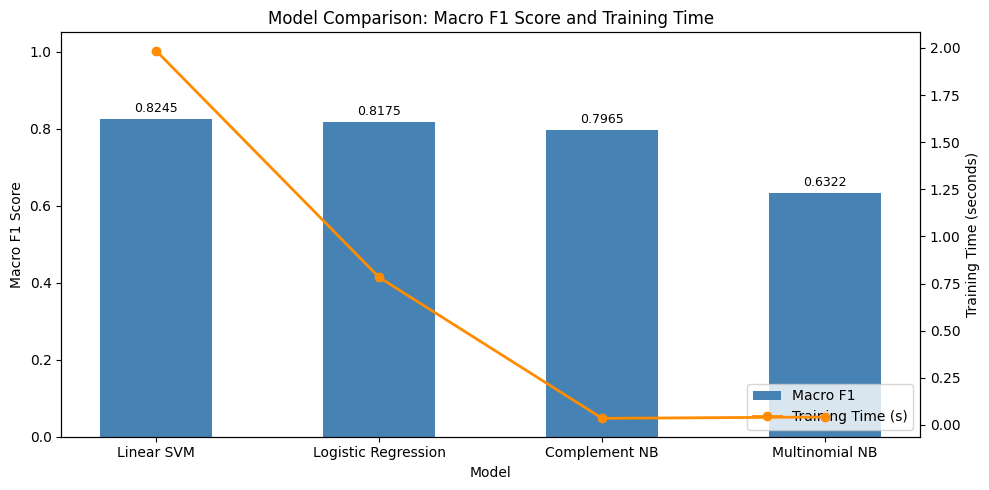

Saved: ..\outputs\figures\model_comparison.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np

model_names = metrics_df['model'].tolist()
f1_scores   = metrics_df['f1_macro'].tolist()
train_times = metrics_df['training_time_s'].tolist()

x = np.arange(len(model_names))

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(x, f1_scores, color='steelblue', width=0.5, label='Macro F1')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.set_xlabel('Model')
ax1.set_ylabel('Macro F1 Score')
ax1.set_ylim(0, 1.05)
ax1.set_title('Model Comparison: Macro F1 Score and Training Time')
ax1.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, train_times, color='darkorange', marker='o', linewidth=2, label='Training Time (s)')
ax2.set_ylabel('Training Time (seconds)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
out = FIGURES / 'model_comparison.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

In [27]:
winner_name  = metrics_df.iloc[0]['model']
winner_model = trained[winner_name]['model']
winner_res   = results[winner_name]

print(f"Selected model: {winner_name}")
print(f"  Macro F1:       {winner_res['f1_macro']:.4f}")
print(f"  Accuracy:       {winner_res['accuracy']:.4f}")
print(f"  Training time:  {winner_res['training_time']:.2f}s")

Selected model: Linear SVM
  Macro F1:       0.8245
  Accuracy:       0.9059
  Training time:  1.98s


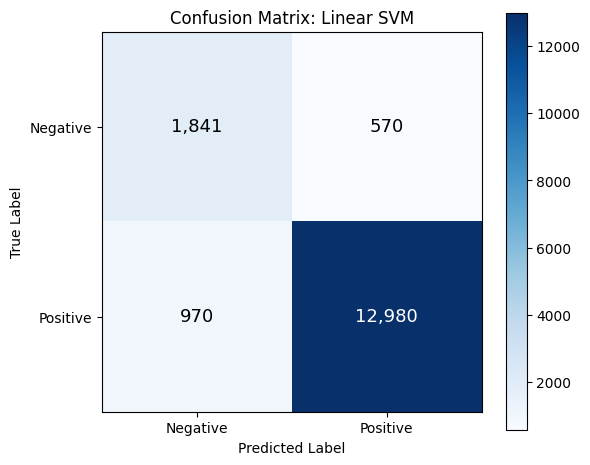

Saved: ..\outputs\figures\confusion_matrix_linear_svm.png


In [28]:
import matplotlib.pyplot as plt

cm     = winner_res['confusion_matrix']
labels = ['Negative', 'Positive']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(
    xticks=[0, 1], yticks=[0, 1],
    xticklabels=labels, yticklabels=labels,
    xlabel='Predicted Label',
    ylabel='True Label',
    title=f'Confusion Matrix: {winner_name}',
)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}',
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=13)
plt.tight_layout()
out = FIGURES / f'confusion_matrix_{winner_name.lower().replace(" ", "_")}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

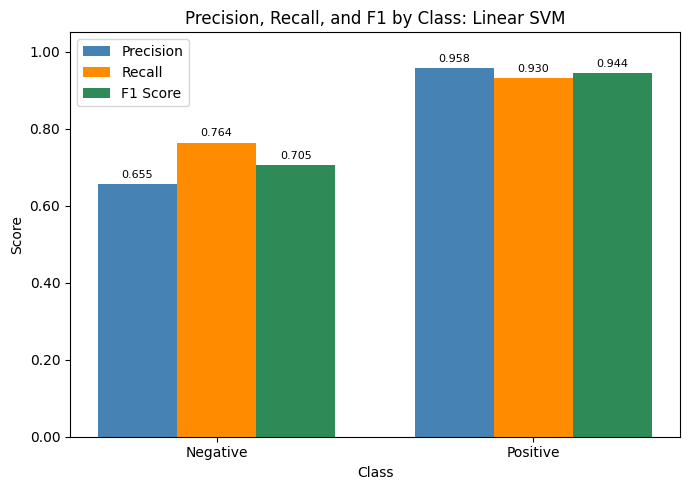

Saved: ..\outputs\figures\metrics_by_class_linear_svm.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

precision = winner_res['precision_per_class']
recall    = winner_res['recall_per_class']
f1        = winner_res['f1_per_class']
labels    = ['Negative', 'Positive']
x         = np.arange(len(labels))
width     = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue')
b2 = ax.bar(x,         recall,    width, label='Recall',    color='darkorange')
b3 = ax.bar(x + width, f1,        width, label='F1 Score',  color='seagreen')
ax.set(
    xticks=x, xticklabels=labels,
    xlabel='Class',
    ylabel='Score',
    title=f'Precision, Recall, and F1 by Class: {winner_name}',
    ylim=(0, 1.05),
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
out = FIGURES / f'metrics_by_class_{winner_name.lower().replace(" ", "_")}.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

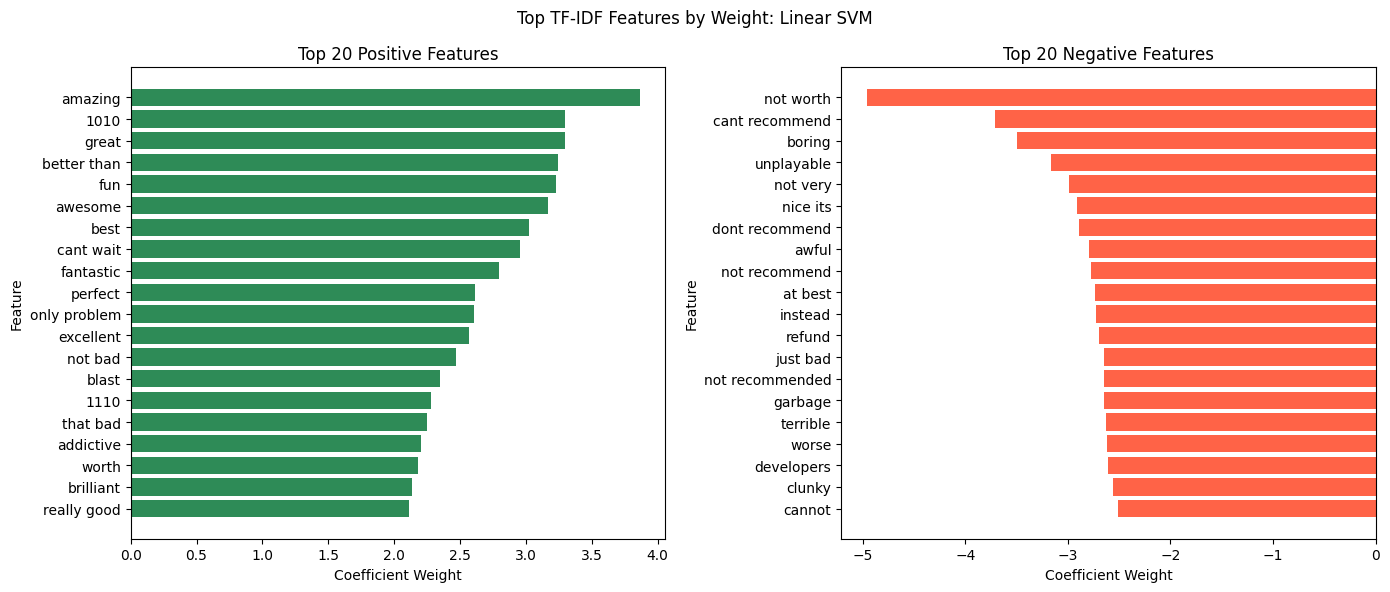

Saved: ..\outputs\figures\top_features_linear_svm.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

if hasattr(winner_model, 'coef_'):
    feature_names = vectorizer.get_feature_names_out()
    coef = winner_model.coef_
    if hasattr(coef, 'toarray'):
        coef = coef.toarray()
    coef = coef.ravel()

    n = 20
    top_pos_idx = np.argsort(coef)[-n:][::-1]
    top_neg_idx = np.argsort(coef)[:n]

    pos_terms   = feature_names[top_pos_idx]
    pos_weights = coef[top_pos_idx]
    neg_terms   = feature_names[top_neg_idx]
    neg_weights = coef[top_neg_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(pos_terms[::-1], pos_weights[::-1], color='seagreen')
    axes[0].set_title(f'Top {n} Positive Features')
    axes[0].set_xlabel('Coefficient Weight')
    axes[0].set_ylabel('Feature')

    axes[1].barh(neg_terms[::-1], neg_weights[::-1], color='tomato')
    axes[1].set_title(f'Top {n} Negative Features')
    axes[1].set_xlabel('Coefficient Weight')
    axes[1].set_ylabel('Feature')

    plt.suptitle(f'Top TF-IDF Features by Weight: {winner_name}')
    plt.tight_layout()
    out = FIGURES / f'top_features_{winner_name.lower().replace(" ", "_")}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved: {out}")
else:
    print(f"{winner_name} does not expose feature coefficients. Skipping top features chart.")

**Model selection: Linear SVM.** Linear SVM achieved the highest macro F1 score (0.8245) and the highest accuracy (90.6%) across all four candidates. It is selected as the primary model.

**Full comparison summary.**

| Model | Accuracy | Macro F1 | Training Time |
|---|---|---|---|
| Linear SVM | 0.9059 | 0.8245 | 1.98s |
| Logistic Regression | 0.8936 | 0.8175 | 0.78s |
| Complement NB | 0.8889 | 0.7965 | 0.035s |
| Multinomial NB | 0.8789 | 0.6322 | 0.042s |

**Linear SVM vs. Logistic Regression.** The gap between Linear SVM and Logistic Regression on macro F1 is 0.007. Logistic Regression trains 2.5 times faster (0.78s vs 1.98s) and achieves slightly higher macro recall (0.872 vs 0.847), meaning it recovers more true negatives. Linear SVM leads on precision and overall F1. Both are strong models; Linear SVM is selected on the stated criterion.

**Complement NB.** Complement NB performed competitively at 0.7965 macro F1 and trained in 0.035 seconds. Its design for imbalanced datasets held up well here, outperforming standard Multinomial NB by a large margin.

**Multinomial NB failure.** Multinomial NB recorded the lowest macro F1 (0.6322) despite its high precision (0.885), driven by extremely low recall (0.600). Without native class weight support, Multinomial NB learned to predict positive aggressively, missing a large share of negative reviews. This confirms that class imbalance correction at the model level is required for this dataset.

**Naive baseline comparison.** A classifier that always predicts positive would achieve 85.3% accuracy on this dataset. Linear SVM at 90.6% is 5.3 percentage points above that floor, and its macro F1 of 0.8245 reflects meaningful performance on both classes, not just the majority class.

**Training time as a tiebreaker.** Training times ranged from 0.03 seconds (Naive Bayes) to 1.98 seconds (Linear SVM). At this scale, all four models are fast enough for practical use. Training time favors Logistic Regression over Linear SVM, but the macro F1 difference was sufficient to maintain Linear SVM as the selection.


## 9. Error Analysis

## 10. Limitations, Bias, and Responsible Use

## 11. Future Integration with AI Game Director Studio

## 12. Final Notebook Summary